In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as ply
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv('../input/titanic/train.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<AxesSubplot:xlabel='Survived', ylabel='count'>

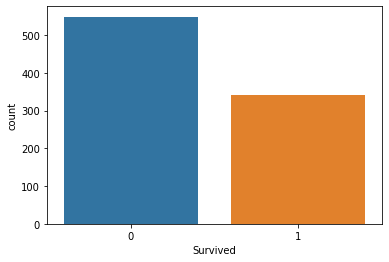

In [6]:
sns.countplot(data=df, x='Survived')


<AxesSubplot:xlabel='Survived', ylabel='count'>

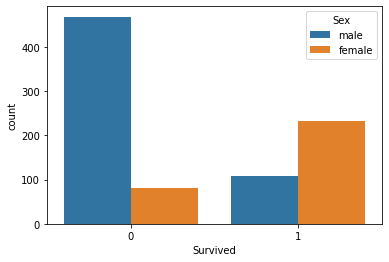

In [7]:
sns.countplot(data=df, x='Survived',hue='Sex')


<AxesSubplot:xlabel='Survived', ylabel='count'>

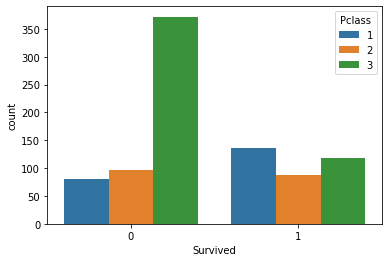

In [8]:
sns.countplot(data=df, x='Survived', hue='Pclass')


<AxesSubplot:xlabel='SibSp', ylabel='count'>

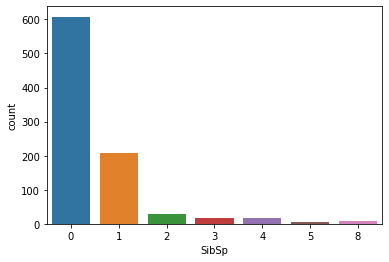

In [9]:
sns.countplot(data=df, x='SibSp')


In [10]:
def missing_percent(df):
    nan_percent= 100*(df.isnull().sum()/len(df))
    nan_percent= nan_percent[nan_percent>0].sort_values()
    return nan_percent

In [11]:
nan_percent= missing_percent(df)
nan_percent


Embarked     0.224467
Age         19.865320
Cabin       77.104377
dtype: float64

<AxesSubplot:>

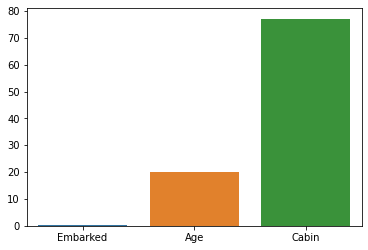

In [12]:
sns.barplot(x=nan_percent.index, y=nan_percent)


In [13]:
df= df.drop('Cabin', axis=1 )

<AxesSubplot:>

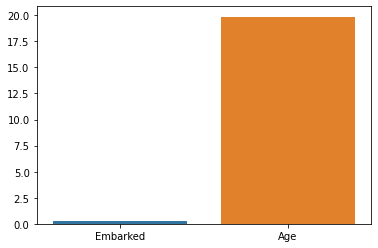

In [14]:
nan_percent= missing_percent(df)
sns.barplot(x=nan_percent.index, y=nan_percent)

In [15]:
df[df['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,NaN


In [16]:
df= df.dropna(subset=['Embarked'], axis=0)


<AxesSubplot:>

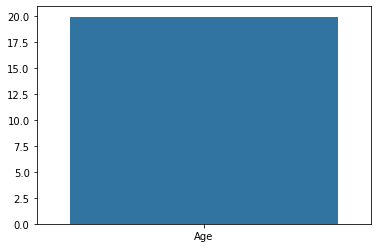

In [17]:
nan_percent= missing_percent(df)
sns.barplot(x=nan_percent.index, y=nan_percent)

<AxesSubplot:xlabel='Pclass', ylabel='Age'>

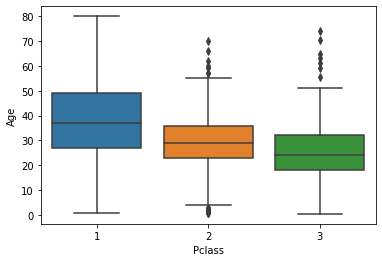

In [18]:
sns.boxplot(data=df, x='Pclass', y='Age')

In [19]:
df.groupby('Pclass')['Age'].mean()

Pclass
1    38.105543
2    29.877630
3    25.140620
Name: Age, dtype: float64

In [20]:
df['Age']= df.groupby('Pclass')['Age'].transform(lambda val: val.fillna(val.mean()))

In [21]:
nan_percent= missing_percent(df)
nan_percent

Series([], dtype: float64)

In [22]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [23]:
df_num= df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
df_obj=df[['Sex', 'Embarked']]

In [24]:
df_obj= pd.get_dummies(df_obj, drop_first=True)


In [25]:
df_obj.shape


(889, 3)

In [26]:
df= pd.concat([df_num, df_obj], axis=1)


In [27]:
X=df.drop('Survived', axis=1)
y=df['Survived']

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [29]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [30]:
scaled_X_train=scaler.fit_transform(X_train)
scaled_X_test= scaler.fit_transform(X_test)

In [31]:
from sklearn.linear_model import LogisticRegression
log_model= LogisticRegression()


In [32]:
log_model.fit(scaled_X_train, y_train)

LogisticRegression()

In [33]:
log_model.coef_


array([[-0.93631372, -0.53385523, -0.27052242, -0.08452825,  0.07486479,
        -1.23862474, -0.04580198, -0.1624084 ]])

In [34]:
y_pred= log_model.predict(scaled_X_test)


In [35]:
pd.DataFrame({'Y_Test': y_test,'Y_Pred':y_pred}).head(5)

,Y_Test,Y_Pred
511,0,0
613,0,0
615,1,1
337,1,1
718,0,0


In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, plot_confusion_matrix

In [37]:
accuracy_score(y_test, y_pred)


0.8239700374531835

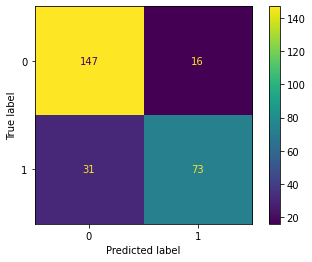

In [38]:
plot_confusion_matrix(log_model, scaled_X_test, y_test)


In [39]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.90      0.86       163
           1       0.82      0.70      0.76       104

    accuracy                           0.82       267
   macro avg       0.82      0.80      0.81       267
weighted avg       0.82      0.82      0.82       267



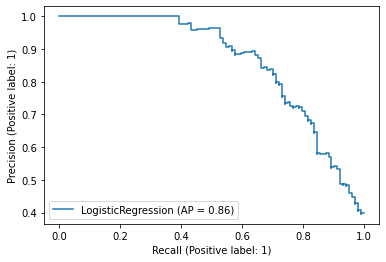

In [40]:
from sklearn.metrics import precision_recall_curve, plot_precision_recall_curve, plot_roc_curve
plot_precision_recall_curve(log_model, scaled_X_test, y_test)


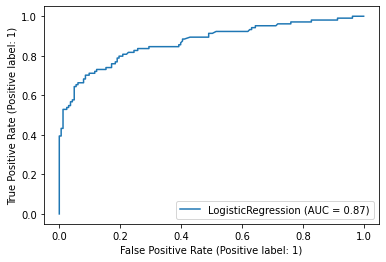

In [41]:
plot_roc_curve(log_model, scaled_X_test, y_test)
